In [ ]:
import os
import geopandas as gpd
import pandas as pd
from netCDF4 import Dataset
import numpy as np

# ================= CONFIGURATION =================
BASE_PATH = '/storage/group/cxs1024/default/mehdi/Hurricane_MatthewData'
GAUGE_SHP_PATH = os.path.join(BASE_PATH, 'UpstreamLocations/UpstreamBoundry_locations.shp')
DISCHARGE_FOLDER = os.path.join(BASE_PATH, 'discharge_1main&7tributaries')
TMS_OUTPUT_FOLDER = os.path.join(BASE_PATH, 'tms_files')

if not os.path.exists(TMS_OUTPUT_FOLDER):
    os.makedirs(TMS_OUTPUT_FOLDER)

# Load Gauge Locations
upstream_gauge = gpd.read_file(GAUGE_SHP_PATH)



import os
import pandas as pd
from netCDF4 import Dataset
import numpy as np

def create_tms_manually(file_path, times, discharges):
    """Creates a NetCDF .tms file with cleaned metadata."""
    # Ensure the directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    
    with Dataset(file_path, 'w', format='NETCDF4') as rootgrp:
        rootgrp.createDimension('time', len(times))
        
        t_var = rootgrp.createVariable('time', 'f8', ('time',))
        q_var = rootgrp.createVariable('discharge', 'f8', ('time',))
        
        t_var[:] = times
        q_var[:] = discharges
        
        # Standard ANUGA NetCDF attributes [cite: 2048, 2052, 2053, 2054]
        rootgrp.description = "Manual conversion for ANUGA"
        rootgrp.starttime = 0.0  
        rootgrp.xllcorner = 0.0 
        rootgrp.yllcorner = 0.0 
        rootgrp.zone = -1        
        rootgrp.projection = "UTM"
        rootgrp.datum = "WGS84"


        
# ================= PROCESS FILES =================
for idx, row in upstream_gauge.iterrows():
    full_name = row['Name']
    usgs_id = full_name.split('_')[-1]
    csv_path = os.path.join(DISCHARGE_FOLDER, f"{usgs_id}.csv")
    tms_output_path = os.path.join(TMS_OUTPUT_FOLDER, f"{usgs_id}.tms")
    
    if not os.path.exists(csv_path):
        continue
    
    try:
        df = pd.read_csv(csv_path, header=0, names=['datetime', 'discharge_m3s'])
        df['datetime'] = pd.to_datetime(df['datetime'])
        
        # Convert to relative seconds from the first record
        start_time = df['datetime'].iloc[0]
        time_seconds = (df['datetime'] - start_time).dt.total_seconds().values
        discharge_values = df['discharge_m3s'].values
        
        create_tms_manually(tms_output_path, time_seconds, discharge_values)
        print(f"✓ Created: {tms_output_path}")
        
    except Exception as e:
        print(f"✗ Error at {full_name}: {e}")

✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8791413.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8790751.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8790719.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8790801.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8790519.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/8790559.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/11235707.tms
✓ Created: /storage/group/cxs1024/default/mehdi/Hurricane_MatthewData/tms_files/11236643.tms


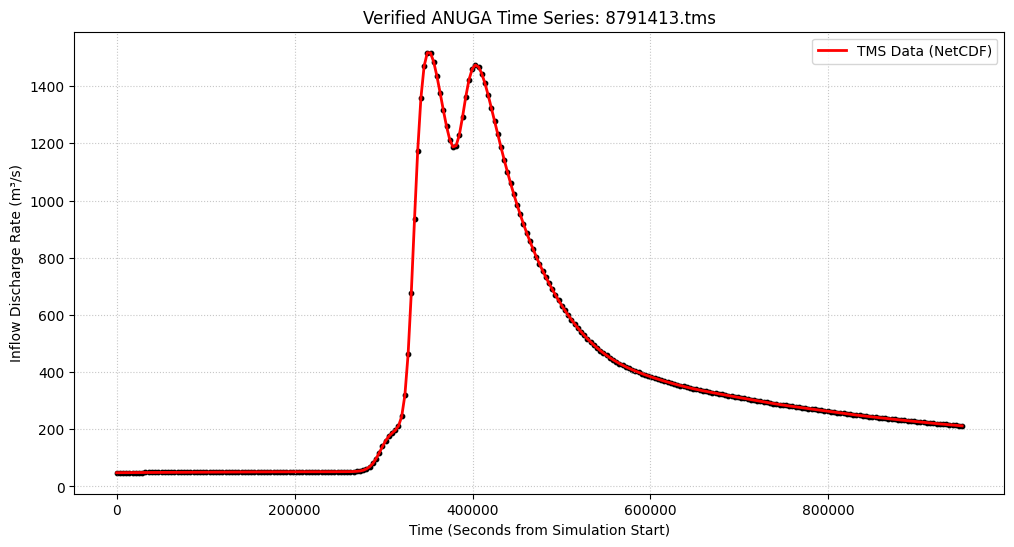

In [2]:
import os
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# Path to the specific .tms file created in the previous step
example_tms = os.path.join(TMS_OUTPUT_FOLDER, '8791413.tms')

if os.path.exists(example_tms):
    # Open the manual NetCDF file
    with Dataset(example_tms, 'r') as rootgrp:
        # Extract variables
        # ANUGA looks for 'time' and a quantity like 'discharge' [cite: 1591, 1613]
        t_data = rootgrp.variables['time'][:]
        q_data = rootgrp.variables['discharge'][:]
        
    # Create the Plot
    plt.figure(figsize=(12, 6))
    plt.plot(t_data, q_data, color='red', linewidth=2, label='TMS Data (NetCDF)')
    plt.scatter(t_data, q_data, color='black', s=10) # Individual hourly points
    
    # Formatting according to ANUGA manual standards [cite: 2602, 2610]
    plt.title(f"Verified ANUGA Time Series: {os.path.basename(example_tms)}")
    plt.xlabel("Time (Seconds from Simulation Start)")
    plt.ylabel("Inflow Discharge Rate (m³/s)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    
    plt.show()
else:
    print(f"File {example_tms} not found. Please run the conversion script first.")